In [2]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import os




In [3]:
# Paths
subject = "sub-racsleep31"
subject_dir = f"/orcd/data/ldlewis/001/om/hf303/for_ore/{subject}/eeg/"
behavior_mat = "/orcd/data/ldlewis/001/om/hf303/pet_eeg_fmri/racsleep31/behav/racsleep31_run01_buttonpresses_clean.mat"

In [4]:
# Load EEG
eeg_files = [f for f in os.listdir(subject_dir) if f.startswith('c') and f.endswith('.mat')]
if len(eeg_files) == 0:
    raise FileNotFoundError("No EEG time series file found.")
eeg_mat_path = os.path.join(subject_dir, eeg_files[0])
eeg_mat = sio.loadmat(eeg_mat_path)
print("EEG MAT keys:", eeg_mat.keys())


if 'ch' in eeg_mat:
    eeg_data = np.squeeze(eeg_mat['ch'])
else:
    #last non-meta value
    candidates = {k: v for k, v in eeg_mat.items() if not k.startswith('__')}
    #the largest 1D array
    eeg_data = max(candidates.values(), key=lambda a: np.size(a))
    eeg_data = np.squeeze(eeg_data)

print("EEG shape (samples):", eeg_data.shape)


EEG MAT keys: dict_keys(['__header__', '__version__', '__globals__', 'cleaned'])
EEG shape (samples): (845600,)


In [5]:
#Load Button Presses 
mat = sio.loadmat(behavior_mat)
press_times = mat['buttonpresses_clean'].flatten()




In [6]:
# Load Spectrogram 
spectrogram_path = os.path.join(subject_dir, "spectrogram.mat")
spec_mat = sio.loadmat(spectrogram_path)
Sxx = np.squeeze(spec_mat['eeg_spec'])
times = np.squeeze(spec_mat['eeg_t'])
freqs = np.squeeze(spec_mat['eeg_f'])

In [7]:
# Convert to decibel scale
Sxx_db = 10 * np.log10(Sxx + 1e-12)

#Limit to 0-20 Hz range 
freq_mask = (freqs >= 0) & (freqs <= 20)
Sxx_db = Sxx_db[:, freq_mask]
freqs = freqs[freq_mask]


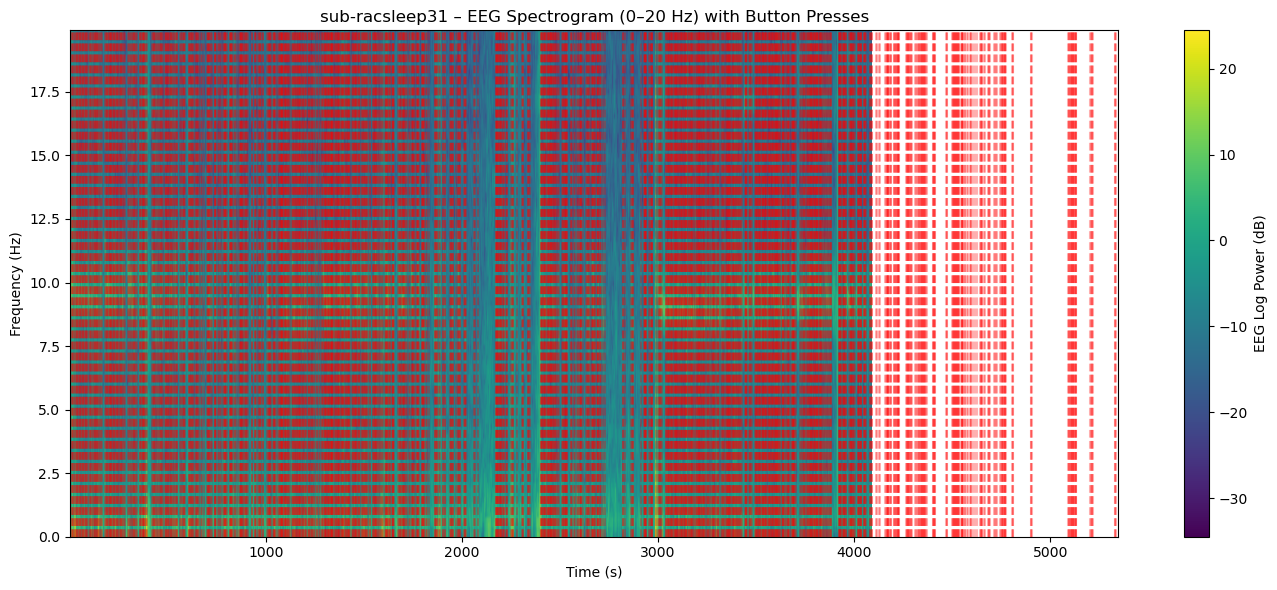

In [8]:
# Compute Alpha (8-12 Hz) and Delta (0.5-4 Hz) Band Power 
alpha_idx = np.where((freqs >= 8) & (freqs <= 12))[0]
delta_idx = np.where((freqs >= 0.5) & (freqs <= 4))[0]

alpha_power = np.mean(Sxx_db[:, alpha_idx], axis=1)
delta_power = np.mean(Sxx_db[:, delta_idx], axis=1)

# Compute ratio
ratio_power = delta_power / (alpha_power + 1e-6)

# Plot Spectrogram with Button Presses 
plt.figure(figsize=(14, 6))
plt.imshow(Sxx_db.T, aspect='auto', origin='lower',
           extent=[times[0], times[-1], freqs[0], freqs[-1]])
plt.colorbar(label='EEG Log Power (dB)')
plt.title(f"{subject} – EEG Spectrogram (0–20 Hz) with Button Presses")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
# overlay button presses
for t in press_times:
    plt.axvline(x=t, color='red', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

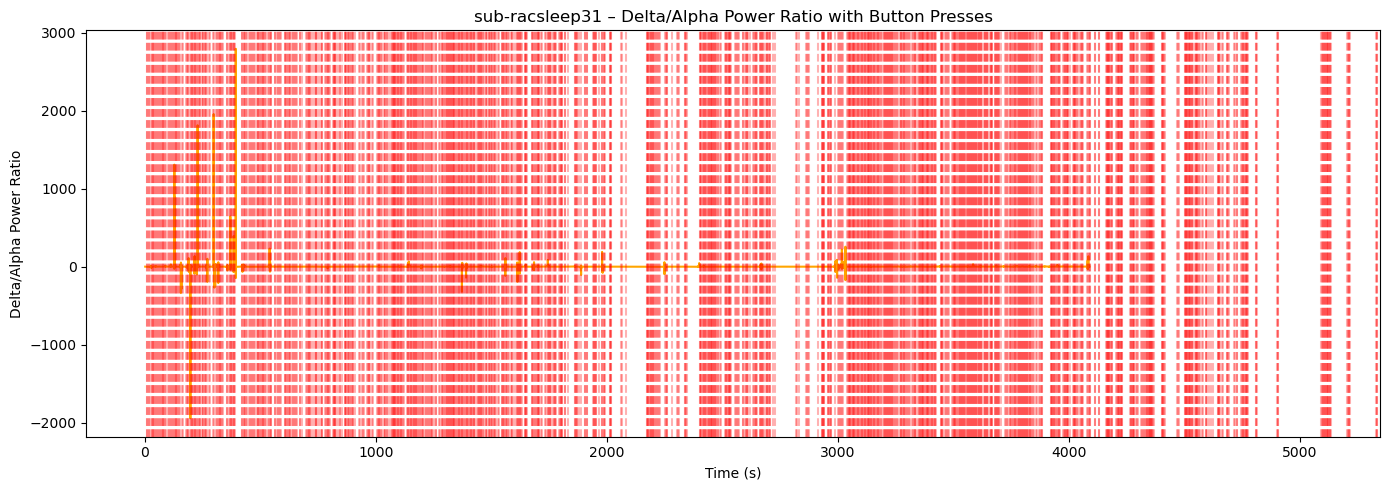

In [9]:


# plot Delta/Alpha Ratio with Button Presses 
plt.figure(figsize=(14, 5))
plt.plot(times, ratio_power, color='orange', linewidth=1.5)
for t in press_times:
    plt.axvline(x=t, color='red', linestyle='--', alpha=0.3)
plt.title(f"{subject} – Delta/Alpha Power Ratio with Button Presses")
plt.xlabel("Time (s)")
plt.ylabel("Delta/Alpha Power Ratio")
plt.tight_layout()
plt.show()


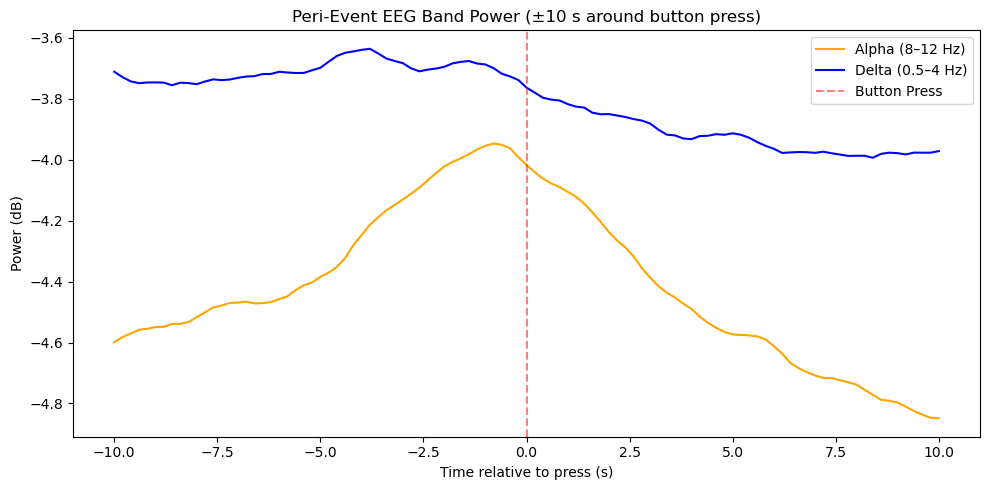

In [10]:
# Peri-Event Analysis (±10s around each button press) 
window = 10  # seconds before and after
fs_spec = len(times) / (times[-1] - times[0])  # approximate spectrogram sampling rate
samples_win = int(window * fs_spec)
peri_times = np.linspace(-window, window, 2 * samples_win + 1)

peri_alpha, peri_delta = [], []
for t in press_times:
    idx = np.argmin(np.abs(times - t))
    start = max(0, idx - samples_win)
    end = min(len(times), idx + samples_win + 1)
    if end - start == len(peri_times):
        peri_alpha.append(alpha_power[start:end])
        peri_delta.append(delta_power[start:end])

peri_alpha = np.array(peri_alpha)
peri_delta = np.array(peri_delta)

# average peri-event band power
alpha_mean = np.mean(peri_alpha, axis=0)
delta_mean = np.mean(peri_delta, axis=0)

# plot peri-event delta & alpha power 
plt.figure(figsize=(10, 5))
plt.plot(peri_times, alpha_mean, label='Alpha (8–12 Hz)', color='orange')
plt.plot(peri_times, delta_mean, label='Delta (0.5–4 Hz)', color='blue')
plt.axvline(0, color='red', linestyle='--', alpha=0.5, label='Button Press')
plt.title("Peri-Event EEG Band Power (±10 s around button press)")
plt.xlabel("Time relative to press (s)")
plt.ylabel("Power (dB)")
plt.legend()
plt.tight_layout()
plt.show()


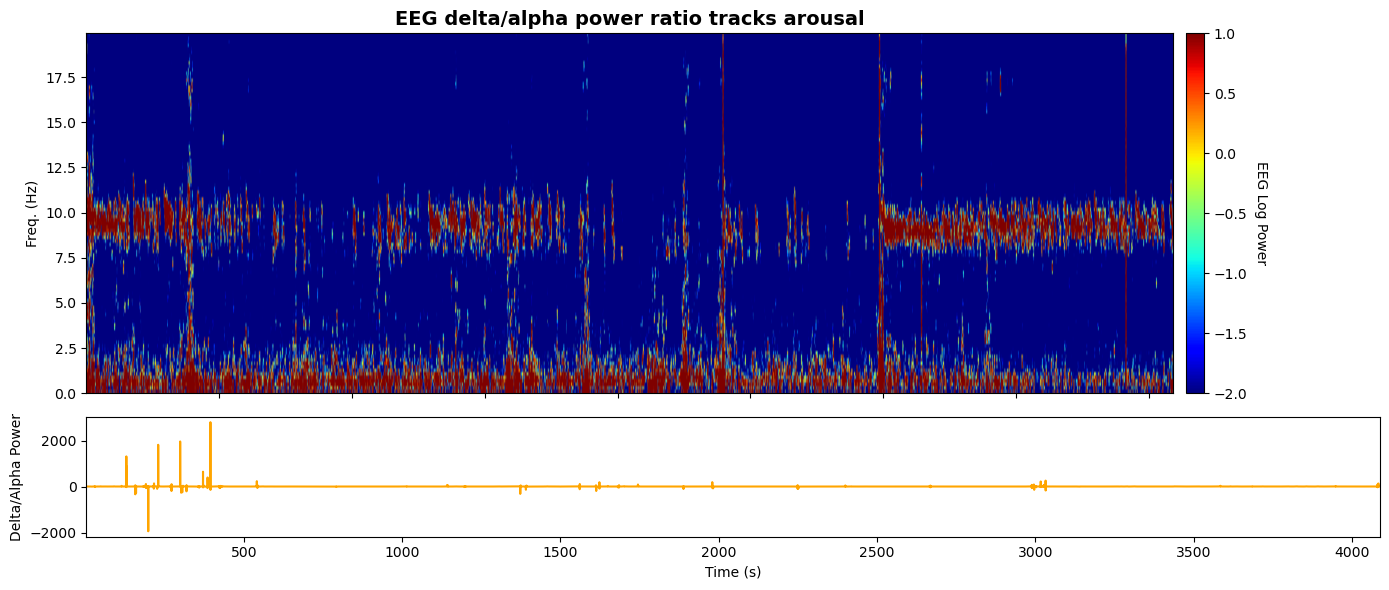

In [12]:
# EEG delta/alpha power ratio tracks Arousal 

fig, axs = plt.subplots(2, 1, figsize=(14, 6), 
                        gridspec_kw={'height_ratios': [3, 1]}, 
                        sharex=True)

# Top panel: EEG Spectrogram
im = axs[0].imshow(
    Sxx_db.T,
    aspect='auto',
    origin='lower',
    extent=[times[0], times[-1], freqs[0], freqs[-1]],
    cmap='jet',
    vmin=-2,
    vmax=1
)
axs[0].set_ylabel("Freq. (Hz)")
axs[0].set_title("EEG delta/alpha power ratio tracks arousal", fontsize=14, weight='bold')
cbar = plt.colorbar(im, ax=axs[0], pad=0.01)
cbar.set_label("EEG Log Power", rotation=270, labelpad=15)

# delta/alpha ratio
axs[1].plot(times, ratio_power, color='orange', linewidth=1.5)
axs[1].set_xlabel("Time (s)")
axs[1].set_ylabel("Delta/Alpha Power")

plt.tight_layout()
plt.show()









In [13]:
# EEG-only arousal detection 
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks

In [14]:
# parameters that are tuned fir each subject
smooth_seconds = 5.0            # smooth Δ/α ratio over 5 s
spec_dt = np.median(np.diff(times))
spec_fs = 1.0 / spec_dt
smooth_sigma = int(max(1, smooth_seconds * spec_fs))

# create smoothed ratio (linear) and z-score
ratio_linear = np.copy(ratio_power)  # delta / alpha (linear)
ratio_smooth = gaussian_filter1d(ratio_linear, sigma=smooth_sigma)

ratio_mean = np.nanmean(ratio_smooth)
ratio_std = np.nanstd(ratio_smooth)
ratio_z = (ratio_smooth - ratio_mean) / (ratio_std + 1e-12)

In [15]:
# Strategy: arousal = local minima in ratio_z (delta/alpha drops)
# convert to peak detection on negative of the ratio
inv = -ratio_z
# find peaks in inv (minima of ratio)
min_distance_seconds = 8.0      # minimum time between detected events
min_distance_bins = int(min_distance_seconds * spec_fs)
prominence = 0.8                # tune: how deep the minimum must be relative to neighbors

peaks, props = find_peaks(inv, distance=min_distance_bins, prominence=prominence)

detected_times = times[peaks]

# also threshold derivative to catch fast changes 
deriv = np.gradient(ratio_smooth, spec_dt)
deriv_thresh = -0.5 * np.std(deriv)  # negative slope threshold for arousal
fast_change_mask = deriv < deriv_thresh
# keep detected peaks where derivative is negative enough near the peak
keep_mask = []
for pk in peaks:
    left = max(0, pk - 2)
    right = min(len(deriv), pk + 3)
    keep_mask.append(np.any(deriv[left:right] < deriv_thresh))
keep_mask = np.array(keep_mask)
peaks = peaks[keep_mask]
detected_times = times[peaks]

# merge events closer than merge_seconds
merge_seconds = 6.0
merged = []
for t in detected_times:
    if not merged:
        merged.append(t)
    else:
        if t - merged[-1] <= merge_seconds:
            # merge by replacing with mean time
            merged[-1] = 0.5 * (merged[-1] + t)
        else:
            merged.append(t)
detected_times = np.array(merged)


In [16]:
# Evaluate vs button-press arousals
# define behavioral arousal times from press_times 
#  if a detected EEG event is within +/- match_window seconds of a behavioral arousal, it's a true positive
match_window = 10.0  # seconds

# set of behavioral arousal times to compare to, I will change later when I add arousal times 
try:
    behavioral_arousals = np.array(arousal_times)  
except NameError:
    behavioral_arousals = press_times  # fallback: use all presses

# match detected -> behavior
tp = 0
fp = 0
fn = 0
matched_behavior_idx = set()
for dt in detected_times:
    # find nearest behavior arousal
    diffs = np.abs(behavioral_arousals - dt)
    if len(diffs) > 0 and diffs.min() <= match_window:
        tp += 1
        matched_behavior_idx.add(np.argmin(diffs))
    else:
        fp += 1
fn = max(0, len(behavioral_arousals) - len(matched_behavior_idx))

precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else np.nan

print(f"Detected EEG events: {len(detected_times)}")
print(f"Behavioral arousals considered: {len(behavioral_arousals)}")
print(f"TP={tp}, FP={fp}, FN={fn}, precision={precision:.3f}, recall={recall:.3f}, F1={f1:.3f}")


Detected EEG events: 1
Behavioral arousals considered: 987
TP=1, FP=0, FN=986, precision=1.000, recall=0.001, F1=0.002


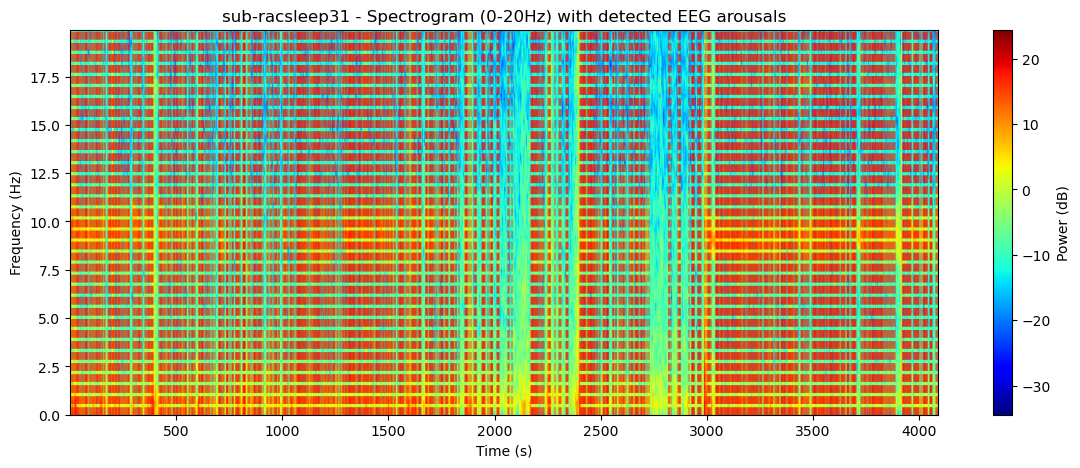

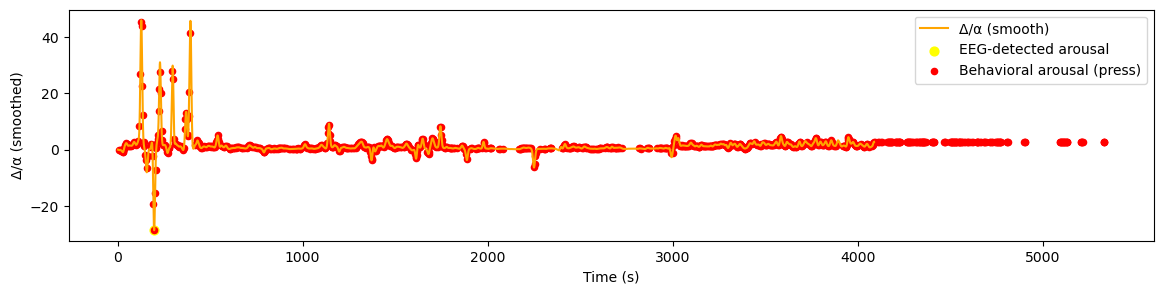

In [17]:
# Plot results 
# (1) Spectrogram with detected events overlay
plt.figure(figsize=(14, 5))
plt.imshow(Sxx_db.T, aspect='auto', origin='lower', extent=[times[0], times[-1], freqs[0], freqs[-1]], cmap='jet')
plt.colorbar(label='Power (dB)')
plt.title(f"{subject} - Spectrogram (0-20Hz) with detected EEG arousals")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")

# overlay detected EEG events and behavioral arousals
for t in detected_times:
    plt.axvline(t, color='yellow', linestyle='-', alpha=0.9, linewidth=1)
for t in behavioral_arousals:
    plt.axvline(t, color='red', linestyle='--', alpha=0.35)
plt.xlim(times[0], times[-1])
plt.show()

# (2) delta/alpha ratio with detected events
plt.figure(figsize=(14, 3))
plt.plot(times, ratio_smooth, color='orange', label='Δ/α (smooth)')
plt.scatter(detected_times, np.interp(detected_times, times, ratio_smooth), color='yellow', s=40, label='EEG-detected arousal')
plt.scatter(behavioral_arousals, np.interp(behavioral_arousals, times, ratio_smooth), color='red', s=20, label='Behavioral arousal (press)')
plt.xlabel('Time (s)')
plt.ylabel('Δ/α (smoothed)')
plt.legend(loc='upper right')
plt.show()


